## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
import sys
import logging

_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(logging.Formatter('[%(levelname)s] %(name)s: %(message)s'))
_log = logging.getLogger('qsoabsfind')
_log.addHandler(_handler)
_log.setLevel(logging.INFO)
_log.propagate = False

In [2]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

import logging
logging.basicConfig(level=logging.INFO)


### Details of input file (DESI DR1 Spectra)

In [3]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'A.Anand '                                                            FIT     = 'NMF     '                                                            SMOOTH  = 'MEDFILT: PIXSIZE=71'                                                 TGTQSO  = 'DESI DR1'                                                            END                                                                                                                                                                                                                                                                                                                                                                     

### Example output catalogs

I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the resulting catalogs to:

- `../data/desi/MgII_cat.fits`
- `../data/desi/CIV_cat.fits`

The configuration used for this run is provided in `data/example_config.yaml`. All other constants are default values.

### Exploring output

[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Loaded 5 extensions from ../data/desi/MgII_cat.fits
[INFO] qsoabsfind.datamodel:   ABSORBER: 36 rows
[INFO] qsoabsfind.datamodel:   METADATA: 36 rows
[INFO] qsoabsfind.datamodel:   COLUMN_DENSITY: 36 rows
[INFO] qsoabsfind.datamodel:   QSO_INFO: 100 rows
[INFO] qsoabsfind.datamodel: Time taken to read catalog from ../data/desi/MgII_cat.fits: 0.05 seconds


Text(0.5, 0, 'MgII redshift')

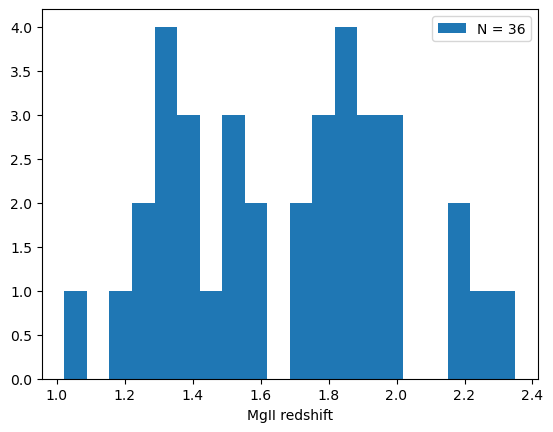

In [4]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/desi/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

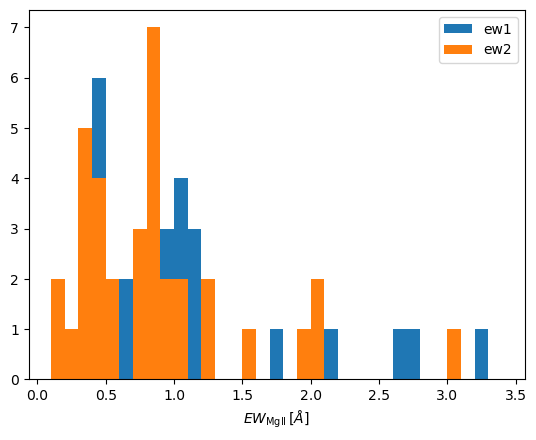

In [5]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 7...
[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.02 seconds


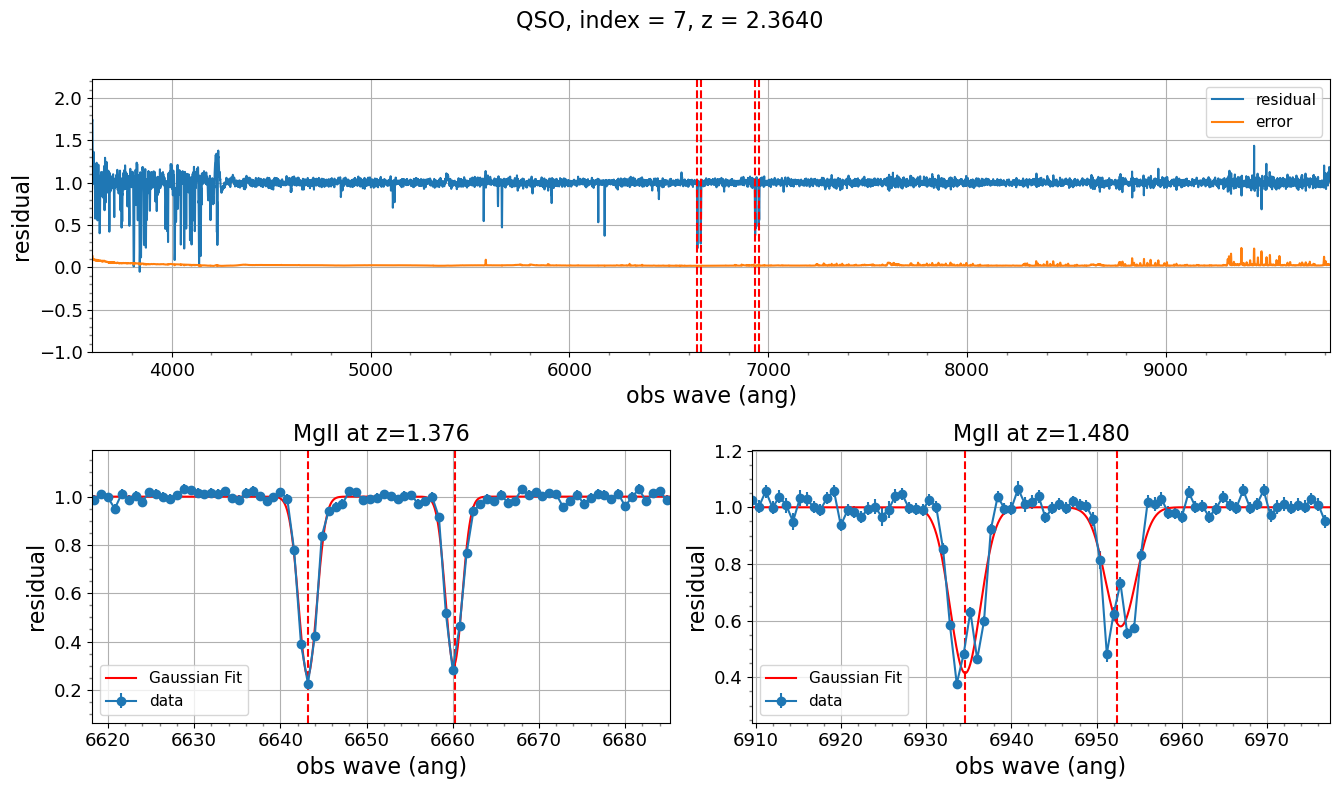

In [6]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = mgii_tab.catalog["INDEX_SPEC"].data[1]
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

2796.3507940001646 2803.4852104341403 0.4419697692589232 0.40454771747144236


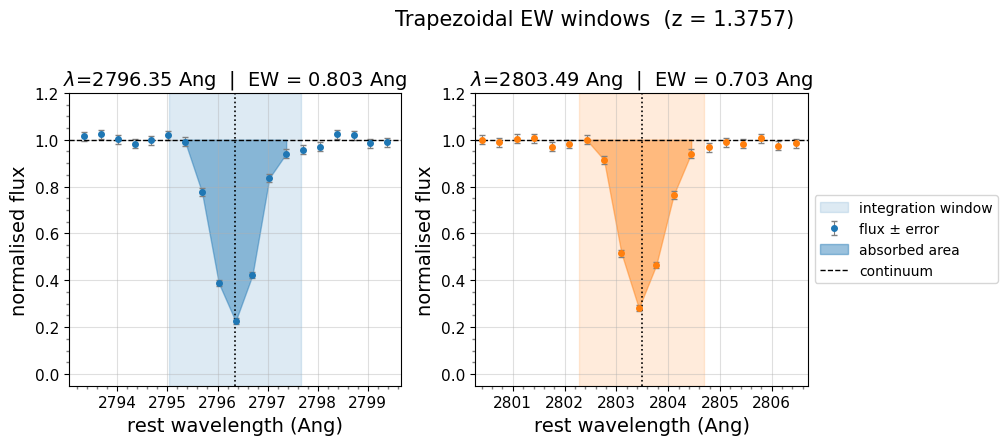

In [7]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z = zabs["Z_ABS"][0]
gauss_fit = zabs["GAUSS_FIT"][0]
line1, line2 = gauss_fit[1], gauss_fit[4]
sigma1, sigma2 = gauss_fit[2], gauss_fit[5]

print(line1, line2, sigma1, sigma2)


plot_trapezoidal_ew_windows(
    spectra.wavelength, spectra.flux, spectra.error, z=z,
    line1=line1, line2=line2,
    sigma1=sigma1, sigma2=sigma2,
    n_sigma=3,
)

### Using qsoabsfind internally as module

In [9]:
parameters = load_constants(f'../data/desi/desi_constants.py')
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:81: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:81: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/opt/anaconda3/envs/my_software/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


{'index_spec': [7, 7],
 'z_abs': [1.3756580424001537, 1.4798745419402155],
 'gauss_fit': [[0.7418906588702165,
   2796.350793999504,
   0.44196976988497894,
   0.6973268117043593,
   2803.485210434253,
   0.4045477165421288],
  [0.5851813249177668,
   2796.349026703996,
   0.7138210784965053,
   0.42030450981231354,
   2803.7000467691714,
   0.7231053294863762]],
 'gauss_fit_std': [[0.010620876968149222,
   0.008377868659351874,
   0.008902473376909782,
   0.01152588170667581,
   0.008707516607334289,
   0.009193386039232658],
  [0.010815930994853576,
   0.015987169999711472,
   0.017022281089643345,
   0.013063111442702491,
   0.028756894707225564,
   0.0281891561709994]],
 'ew_1_mean': [0.8219064474105835, 1.0470556020736694],
 'ew_2_mean': [0.7071247696876526, 0.7618255615234375],
 'ew_total_mean': [1.5290312767028809, 1.808881163597107],
 'ew_1_error': [0.014008453115820885, 0.02086641825735569],
 'ew_2_error': [0.013607801869511604, 0.026402916759252548],
 'ew_total_error': [0.019

[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Loaded 5 extensions from ../data/desi/CIV_cat.fits
[INFO] qsoabsfind.datamodel:   ABSORBER: 8 rows
[INFO] qsoabsfind.datamodel:   METADATA: 8 rows
[INFO] qsoabsfind.datamodel:   COLUMN_DENSITY: 8 rows
[INFO] qsoabsfind.datamodel:   QSO_INFO: 100 rows
[INFO] qsoabsfind.datamodel: Time taken to read catalog from ../data/desi/CIV_cat.fits: 0.09 seconds


Text(0.5, 0, 'CIV redshift')

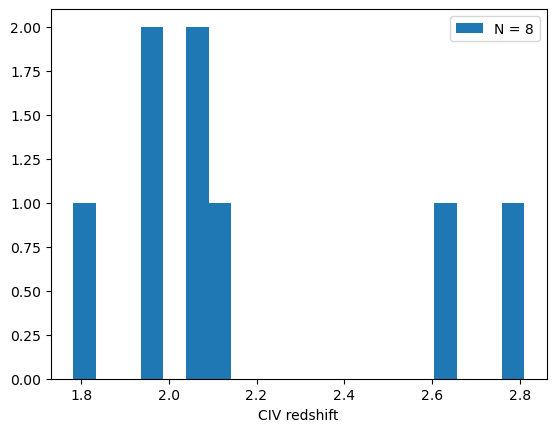

In [10]:
civ_tab = AbsorberData(f'../data/desi/CIV_cat.fits', autoload=True)
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

[INFO] qsoabsfind.datamodel: Time taken to read ../data/desi/qso_test_spectra.fits: 0.03 seconds
INFO: plotting CIV for QSO INDEX = 90...


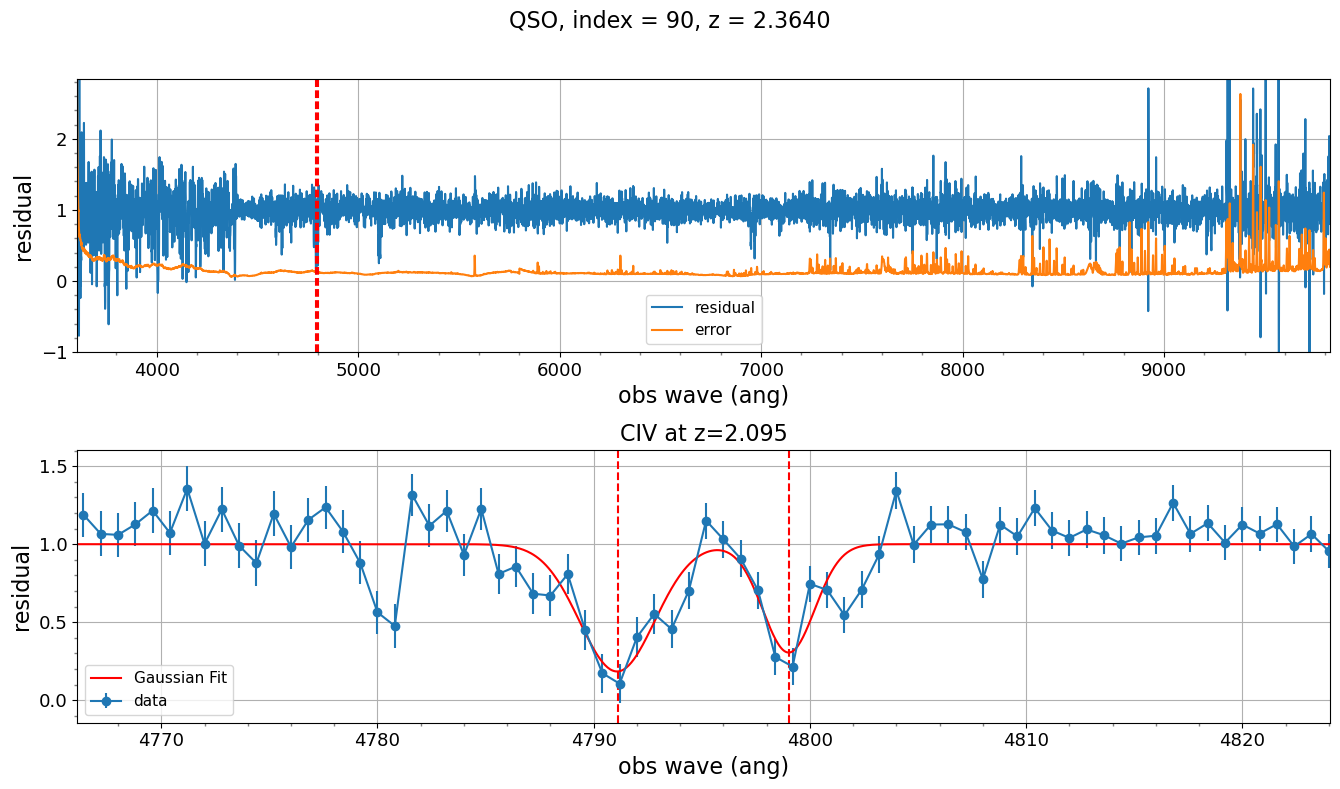

In [11]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from MgII_cat.fits
index1 = civ_tab.catalog["INDEX_SPEC"].data[7]
spectra1 = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index1, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index1}...')
# select corresponding zabs table
zabs1 = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index1]
plot_absorber(spectra1, 'CIV', zabs1, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index1}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

1548.1928548272804 1550.7582252389254 0.560115111147762 0.3862177489691789


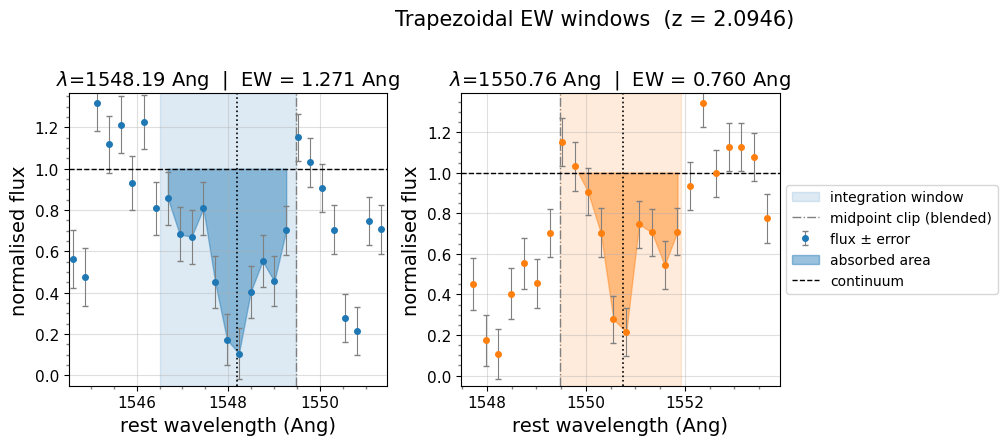

In [12]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z1 = zabs1["Z_ABS"][0]
gauss_fit1 = zabs1["GAUSS_FIT"][0]
line1_1, line2_1 = gauss_fit1[1], gauss_fit1[4]
sigma1_1, sigma2_1 = gauss_fit1[2], gauss_fit1[5]

print(line1_1, line2_1, sigma1_1, sigma2_1)


plot_trapezoidal_ew_windows(
    spectra1.wavelength, spectra1.flux, spectra1.error, z=z1,
    line1=line1_1, line2=line2_1,
    sigma1=sigma1_1, sigma2=sigma2_1,
    n_sigma=3,
)